# CS802 Section 2 - Neural Network from Scratch

This notebook implements a fully connected feed-forward neural network from scratch in NumPy and compares it with the perceptron baselines from Section 1.

1. sigmoid neural network with mini-batch learning,
2. weight/bias initialisation across hidden layers,
3. binary and multi-class classification support,
4. ReLU activation and model tuning,
5. analysis comparing perceptron, sigmoid NN, and ReLU NN results.

## Methodological scope

The analysis makes the main neural-network design choices explicit: initialisation, dropout, validation, early stopping, learning-rate choices, and the distinction between raw-label and aligned-label test diagnostics.


## Setup: imports, constants, and helper functions

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# The notebooks can be run either from the repository root or from the notebooks/ folder.
# The first existing directory containing the CSV files is used.
CANDIDATE_DATA_DIRS = [Path("../data/raw"), Path("data/raw"), Path(".")]
DATA_DIR = next(
    (path for path in CANDIDATE_DATA_DIRS if (path / "sign_mnist_train.csv").exists()),
    CANDIDATE_DATA_DIRS[0],
)

LETTERS = list("ABCDEFGHIKLMNOPQRSTUVWXY")  # J and Z are excluded in Sign Language MNIST.
LABEL_TO_LETTER = {i: letter for i, letter in enumerate(LETTERS)}
NUM_CLASSES = 24
TARGET_CLASS = 2  # Class C is used for binary comparison with the perceptron baseline.


In [2]:
# Data loading
def _read_sign_csv(csv_path):
    preview = pd.read_csv(csv_path, header=None, nrows=3)
    first_value = str(preview.iloc[0, 0]).strip().lower()
    if first_value == "label":
        return pd.read_csv(csv_path)
    return pd.read_csv(csv_path, header=None)

def load_sign_mnist(csv_path, normalize=True):
    df = _read_sign_csv(csv_path)
    y = pd.to_numeric(df.iloc[:, 0], errors="raise").to_numpy(dtype=np.int64)
    X = df.iloc[:, 1:].to_numpy(dtype=np.float32)
    if normalize:
        X = X / 255.0
    return X, y

def make_binary_labels(y, positive_label):
    return (np.asarray(y) == positive_label).astype(np.int64)

def one_hot_encode(y, num_classes=NUM_CLASSES):
    y = np.asarray(y).astype(np.int64)
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

In [3]:
# Metrics and plots
def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(np.int64).ravel()
    y_pred = np.asarray(y_pred).astype(np.int64).ravel()

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "accuracy": float((tp + tn) / len(y_true)),
        "precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
    }

def confusion_matrix_manual(y_true, y_pred, num_classes=NUM_CLASSES):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_label, pred_label in zip(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()):
        if 0 <= true_label < num_classes and 0 <= pred_label < num_classes:
            cm[int(true_label), int(pred_label)] += 1
    return cm

def macro_precision_recall(cm):
    # Note Sign Language MNIST here: the provided test split is missing class 23, so averaging blindly over all 24 rows/columns would
    # unfairly push the macro scores down. The macro average therefore uses only classes that are present in the test set or predicted by the model.
    active_classes = [k for k in range(cm.shape[0]) if (cm[k, :].sum() + cm[:, k].sum()) > 0]
    precisions, recalls = [], []
    for k in active_classes:
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        precisions.append(tp / (tp + fp) if (tp + fp) else 0.0)
        recalls.append(tp / (tp + fn) if (tp + fn) else 0.0)
    return float(np.mean(precisions)), float(np.mean(recalls))

def show_example(X, y, label_id):
    idx = np.where(np.asarray(y) == label_id)[0][0]
    plt.figure(figsize=(3, 3))
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Example: class {label_id} = {LABEL_TO_LETTER[label_id]}")
    plt.axis("off")
    plt.show()

def plot_history(history, title="Training history"):
    hist = pd.DataFrame(history)
    if hist.empty:
        return

    plt.figure(figsize=(6, 4))
    plt.plot(hist["epoch"], hist["loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} – loss")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hist["epoch"], hist["accuracy"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} – accuracy")
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_matrix(cm, labels=None, title="Confusion matrix", figsize=(8, 8)):
    if labels is None:
        labels = [LABEL_TO_LETTER[i] for i in range(cm.shape[0])]
    plt.figure(figsize=figsize)
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 2.1-2.2 ANN class and parameter initialisation

The class below is the core neural-network implementation. It supports:

- any number of hidden layers,
- sigmoid or ReLU hidden activations,
- sigmoid output for binary classification,
- softmax output for multi-class classification,
- Xavier-style initialisation for sigmoid hidden layers,
- He initialisation for ReLU hidden layers,
- mini-batch gradient descent with backpropagation,
- optional L2 regularisation, momentum, learning-rate decay, and inverted dropout.

The code is intentionally written from scratch using NumPy operations such as `@` matrix multiplication so that each part of the forward and backward pass remains inspectable.


In [4]:
class ANN:
    """Fully connected neural network implemented from scratch in NumPy.

    The class intentionally avoids high-level machine-learning libraries. It is
    designed to demonstrate the mechanics of feed-forward prediction,
    mini-batch training, backpropagation, and evaluation for both binary and
    multi-class classification.
    """

    def __init__(
        self,
        no_inputs,
        hidden_layers=None,
        output_nodes=1,
        no_outputs=None,
        max_iterations=20,
        learning_rate=0.01,
        batch_size=128,
        activation="sigmoid",
        random_state=42,
        l2_lambda=0.0,
        momentum=0.0,
        lr_decay=0.0,
        dropout_rate=0.0,
    ):
        # Backwards-compatible alias used in some starter templates.
        if no_outputs is not None:
            output_nodes = no_outputs
        if hidden_layers is None:
            hidden_layers = [128, 64]

        self.no_inputs = int(no_inputs)
        self.hidden_layers = list(hidden_layers)
        self.output_nodes = int(output_nodes)
        self.max_iter = int(max_iterations)
        self.learning_rate = float(learning_rate)
        self.initial_lr = float(learning_rate)
        self.batch_size = int(batch_size)
        self.activation_name = activation.lower()
        self.random_state = int(random_state)
        self.l2_lambda = float(l2_lambda)
        self.momentum = float(momentum)
        self.lr_decay = float(lr_decay)
        self.dropout_rate = float(dropout_rate)
        self.history = []

        if self.activation_name not in {"sigmoid", "relu"}:
            raise ValueError("activation must be 'sigmoid' or 'relu'")
        if not 0.0 <= self.dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in the interval [0, 1)")

        self.layer_sizes = [self.no_inputs] + self.hidden_layers + [self.output_nodes]
        self.weights = []
        self.biases = []
        self.velocity_w = []
        self.velocity_b = []

        # One RNG is kept on the model so dropout and shuffling are reproducible
        # but still vary naturally from epoch to epoch.
        self.rng = np.random.default_rng(self.random_state)

        for layer_idx, (fan_in, fan_out) in enumerate(zip(self.layer_sizes[:-1], self.layer_sizes[1:])):
            is_hidden = layer_idx < len(self.hidden_layers)

            # He initialisation keeps ReLU activations well-scaled. Xavier-style
            # scaling is used for sigmoid layers, where too-large weights can
            # quickly saturate the activation function.
            if is_hidden and self.activation_name == "relu":
                scale = np.sqrt(2.0 / fan_in)
            else:
                scale = np.sqrt(1.0 / fan_in)

            W = self.rng.normal(0.0, scale, size=(fan_in, fan_out)).astype(np.float32)
            b = np.zeros((1, fan_out), dtype=np.float32)
            self.weights.append(W)
            self.biases.append(b)
            self.velocity_w.append(np.zeros_like(W))
            self.velocity_b.append(np.zeros_like(b))

    def describe_architecture(self):
        """Return a compact table describing every layer in the network."""
        rows = []
        for layer_idx, (fan_in, fan_out) in enumerate(zip(self.layer_sizes[:-1], self.layer_sizes[1:]), start=1):
            layer_type = "output" if layer_idx == len(self.layer_sizes) - 1 else "hidden"
            rows.append({
                "layer": layer_idx,
                "type": layer_type,
                "fan_in": fan_in,
                "fan_out": fan_out,
                "weights_shape": self.weights[layer_idx - 1].shape,
                "bias_shape": self.biases[layer_idx - 1].shape,
            })
        return pd.DataFrame(rows)

    # ---------- activation functions ----------
    def activate(self, a, activation=None):
        act = self.activation_name if activation is None else activation.lower()
        if act == "sigmoid":
            # Clipping avoids overflow in exp while preserving saturated outputs.
            return 1.0 / (1.0 + np.exp(-np.clip(a, -40, 40)))
        if act == "relu":
            return np.maximum(0.0, a)
        raise ValueError(f"Unknown activation: {act}")

    def activation_derivative(self, a, activation=None):
        act = self.activation_name if activation is None else activation.lower()
        if act == "sigmoid":
            s = self.activate(a, "sigmoid")
            return s * (1.0 - s)
        if act == "relu":
            return (a > 0).astype(np.float32)
        raise ValueError(f"Unknown activation: {act}")

    def softmax(self, z):
        # Subtract the row-wise max for numerical stability before exponentiating.
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # ---------- forward pass ----------
    def do_predict(self, x, return_cache=False, training=False):
        X = np.asarray(x, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        activations = [X]
        pre_activations = []
        dropout_masks = []
        current = X

        for layer in range(len(self.hidden_layers)):
            z = current @ self.weights[layer] + self.biases[layer]
            pre_activations.append(z)
            h = self.activate(z)

            # Inverted dropout is applied only during training. Dividing by the
            # keep probability means no rescaling is needed at test time.
            if training and self.dropout_rate > 0.0:
                mask = (self.rng.random(h.shape) > self.dropout_rate).astype(np.float32)
                h = h * mask / (1.0 - self.dropout_rate)
            else:
                mask = np.ones_like(h)

            dropout_masks.append(mask)
            current = h
            activations.append(current)

        z_out = current @ self.weights[-1] + self.biases[-1]
        pre_activations.append(z_out)

        # Binary classification uses one sigmoid output; multi-class uses softmax.
        output = self.activate(z_out, "sigmoid") if self.output_nodes == 1 else self.softmax(z_out)
        activations.append(output)

        if return_cache:
            return output, {
                "activations": activations,
                "pre_activations": pre_activations,
                "dropout_masks": dropout_masks,
            }
        return output

    # ---------- mini-batch training with backpropagation ----------
    def do_train(self, training_data, labels):
        X = np.asarray(training_data, dtype=np.float32)
        y = np.asarray(labels, dtype=np.float32)

        if self.output_nodes == 1 and y.ndim == 1:
            y = y.reshape(-1, 1)
        elif self.output_nodes > 1 and y.ndim == 1:
            tmp = np.zeros((len(y), self.output_nodes), dtype=np.float32)
            tmp[np.arange(len(y)), y.astype(np.int64)] = 1.0
            y = tmp

        self.history = []
        n_samples = len(X)

        for epoch in range(self.max_iter):
            current_lr = self.initial_lr / (1.0 + self.lr_decay * epoch)
            indices = self.rng.permutation(n_samples)
            X_shuf = X[indices]
            y_shuf = y[indices]

            epoch_loss = 0.0
            epoch_correct = 0

            for start in range(0, n_samples, self.batch_size):
                Xb = X_shuf[start:start + self.batch_size]
                yb = y_shuf[start:start + self.batch_size]
                batch_size_actual = len(Xb)
                eps = 1e-7

                # Forward pass stores all activations and pre-activations needed
                # for the backward pass.
                out, cache = self.do_predict(Xb, return_cache=True, training=True)
                acts = cache["activations"]
                pre = cache["pre_activations"]
                masks = cache["dropout_masks"]

                if self.output_nodes == 1:
                    batch_loss = -np.mean(
                        yb * np.log(out + eps) + (1.0 - yb) * np.log(1.0 - out + eps)
                    )
                    delta = out - yb
                    epoch_correct += int(np.sum((out >= 0.5).astype(np.int64) == yb.astype(np.int64)))
                else:
                    batch_loss = -np.mean(np.sum(yb * np.log(out + eps), axis=1))
                    delta = out - yb
                    epoch_correct += int(np.sum(np.argmax(out, axis=1) == np.argmax(yb, axis=1)))

                if self.l2_lambda > 0:
                    batch_loss += 0.5 * self.l2_lambda * sum(np.sum(w * w) for w in self.weights)
                epoch_loss += float(batch_loss) * batch_size_actual

                grad_w = [None] * len(self.weights)
                grad_b = [None] * len(self.biases)

                # Backpropagate from output layer to first hidden layer.
                for layer in reversed(range(len(self.weights))):
                    grad_w[layer] = (acts[layer].T @ delta) / batch_size_actual
                    grad_b[layer] = np.mean(delta, axis=0, keepdims=True)

                    if self.l2_lambda > 0:
                        grad_w[layer] += self.l2_lambda * self.weights[layer]

                    if layer > 0:
                        delta = (delta @ self.weights[layer].T) * self.activation_derivative(pre[layer - 1])
                        if self.dropout_rate > 0.0:
                            # The same dropout mask used in the forward pass must
                            # also mask the backward gradient for that layer.
                            delta = delta * masks[layer - 1] / (1.0 - self.dropout_rate)

                # Apply either vanilla SGD or momentum-based updates.
                for layer in range(len(self.weights)):
                    if self.momentum > 0:
                        self.velocity_w[layer] = self.momentum * self.velocity_w[layer] - current_lr * grad_w[layer]
                        self.velocity_b[layer] = self.momentum * self.velocity_b[layer] - current_lr * grad_b[layer]
                        self.weights[layer] += self.velocity_w[layer]
                        self.biases[layer] += self.velocity_b[layer]
                    else:
                        self.weights[layer] -= current_lr * grad_w[layer]
                        self.biases[layer] -= current_lr * grad_b[layer]

            self.history.append({
                "epoch": epoch + 1,
                "loss": epoch_loss / n_samples,
                "accuracy": epoch_correct / n_samples,
            })

        return self.history

    # ---------- evaluation ----------
    def test(self, testing_data, labels, verbose=True):
        X = np.asarray(testing_data, dtype=np.float32)
        y = np.asarray(labels)
        outputs = self.do_predict(X)  # Dropout is automatically off at test time.

        if self.output_nodes == 1:
            y_true = y.reshape(-1).astype(np.int64)
            y_pred = (outputs >= 0.5).astype(np.int64).reshape(-1)
            metrics = binary_metrics(y_true, y_pred)
            cm = np.array([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]], dtype=np.int64)
            results = {
                "confusion_matrix": cm,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "y_pred": y_pred,
                "outputs": outputs,
            }
        else:
            y_true = np.argmax(y, axis=1).astype(np.int64) if y.ndim == 2 else y.astype(np.int64)
            y_pred = np.argmax(outputs, axis=1).astype(np.int64)
            cm = confusion_matrix_manual(y_true, y_pred, num_classes=self.output_nodes)
            precision, recall = macro_precision_recall(cm)
            accuracy = float(np.mean(y_pred == y_true))
            results = {
                "confusion_matrix": cm,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "y_pred": y_pred,
                "outputs": outputs,
            }

        if verbose:
            print("Accuracy:\t", results["accuracy"])
            print("Precision:\t", results["precision"])
            print("Recall:\t", results["recall"])
        return results


## Dataset loading, target preparation, and evaluation note

This section loads the training and test CSV files, prepares both binary and multi-class targets, and builds the standardised inputs used for the stronger neural-network runs. For transparent reporting, the notebook keeps both:

- the **raw test labels** exactly as stored in `sign_mnist_test.csv`,
- an **aligned-label version** used for the final diagnostic evaluation after the label-compression issue was identified.


Train X: (27455, 784) Train y: (27455,)
Test X : (7172, 784) Test y : (7172,)
NN train X: (27455, 784) NN test X: (7172, 784)
Binary target: 2 C
Positive train samples: 1144
Positive test samples : 310
Unique labels in train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Unique labels in raw test : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Unique labels in aligned multi-class test : [ 0  1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23]
Missing labels in raw test: [23]
Missing labels in aligned test: [10]
NO_INPUTS: 784
NO_OUTPUTS: 24


,label,train_count,letter
0,0,1126,A
1,1,1010,B
2,2,1144,C
3,3,1196,D
4,4,957,E
5,5,1204,F
6,6,1090,G
7,7,1013,H
8,8,1162,I
9,9,1114,K


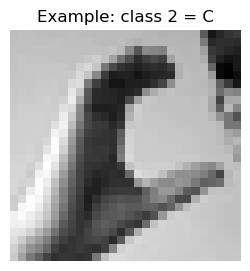

In [5]:
train_path = DATA_DIR / "sign_mnist_train.csv"
test_path = DATA_DIR / "sign_mnist_test.csv"

# Base version:
# I load the dataset and apply normalization directly inside the loader.
X_train, y_train = load_sign_mnist(train_path, normalize=True)
X_test, y_test = load_sign_mnist(test_path, normalize=True)

# Dataset note:
# I noticed that the test dataset does not include all 24 classes. It looks like labels >= 10 are shifted (compressed), so I keep
# the raw labels and create an aligned version for proper multi-class evaluation. Binary setup stays unchanged since TARGET_CLASS = 2.
y_test_multiclass_eval = y_test.copy()
y_test_multiclass_eval[y_test_multiclass_eval >= 10] += 1

y_train_binary = make_binary_labels(y_train, TARGET_CLASS)
y_test_binary = make_binary_labels(y_test, TARGET_CLASS)

# I keep both spellings (one_hot / onehot) to avoid breaking anything later
# in case I accidentally reference a different variable name.
y_train_one_hot = one_hot_encode(y_train, NUM_CLASSES)
y_train_onehot = y_train_one_hot

# Extra preprocessing for neural network experiments:
# I calculate mean and std only on the training set and reuse them for test data, so there is no data leakage.
pixel_mean = X_train.mean(axis=0, keepdims=True)
pixel_std = X_train.std(axis=0, keepdims=True) + 1e-6
X_train_nn = (X_train - pixel_mean) / pixel_std
X_test_nn = (X_test - pixel_mean) / pixel_std

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test X :", X_test.shape, "Test y :", y_test.shape)
print("NN train X:", X_train_nn.shape, "NN test X:", X_test_nn.shape)
print("Binary target:", TARGET_CLASS, LABEL_TO_LETTER[TARGET_CLASS])
print("Positive train samples:", int(y_train_binary.sum()))
print("Positive test samples :", int(y_test_binary.sum()))
print("Unique labels in train:", np.unique(y_train))
print("Unique labels in raw test :", np.unique(y_test))
print("Unique labels in aligned multi-class test :", np.unique(y_test_multiclass_eval))
print("Missing labels in raw test:", sorted(set(range(NUM_CLASSES)) - set(np.unique(y_test))))
print("Missing labels in aligned test:", sorted(set(range(NUM_CLASSES)) - set(np.unique(y_test_multiclass_eval))))

# Simple aliases for later cells so the notebook stays consistent with the naming used in my earlier screenshots.
# I keep the inputs as standard [0,1] normalised pixels here. In some earlier versions I also tried X_train - 0.5, but that
# pushed the baseline ReLU result down to about 40%, even though the same model can go above 85% on plain normalised inputs.

NO_OUTPUTS = NUM_CLASSES
X_train_mc = X_train
X_test_mc = X_test
NO_INPUTS = X_train_mc.shape[1]

print("NO_INPUTS:", NO_INPUTS)
print("NO_OUTPUTS:", NO_OUTPUTS)

distribution = pd.DataFrame({
    "label": sorted(pd.Series(y_train).value_counts().index),
    "train_count": pd.Series(y_train).value_counts().sort_index().values,
})
distribution["letter"] = distribution["label"].map(LABEL_TO_LETTER)
display(distribution.head(10))
show_example(X_train, y_train, TARGET_CLASS)


## Binary neural-network sanity check for 2.4: class C vs rest

The binary experiments provide a controlled comparison with the perceptron baseline from Section 1. They also verify that the forward pass, cross-entropy loss, backpropagation, and testing code are working before the more difficult multi-class experiments.

The comparison uses both sigmoid and ReLU hidden activations. The ReLU run uses momentum because ReLU networks usually benefit from faster, smoother optimisation when gradients are not saturated.


In [6]:

def run_binary_ann_experiment(
    X_train,
    y_train_binary,
    X_test,
    y_test_binary,
    hidden_layers=[128],
    activation="sigmoid",
    learning_rate=0.05,
    max_iterations=15,
    batch_size=128,
    random_state=42,
    l2_lambda=0.0,
    momentum=0.0,
    lr_decay=0.0,
):
    net = ANN(
        no_inputs=X_train.shape[1],
        hidden_layers=hidden_layers,
        output_nodes=1,
        max_iterations=max_iterations,
        learning_rate=learning_rate,
        batch_size=batch_size,
        activation=activation,
        random_state=random_state,
        l2_lambda=l2_lambda,
        momentum=momentum,
        lr_decay=lr_decay,
    )

    start_time = time.time()
    history = net.do_train(X_train, y_train_binary)
    training_time = time.time() - start_time
    results = net.test(X_test, y_test_binary, verbose=False)

    summary = {
        "activation": activation,
        "hidden_layers": str(hidden_layers),
        "learning_rate": learning_rate,
        "max_iterations": max_iterations,
        "batch_size": batch_size,
        "l2_lambda": l2_lambda,
        "momentum": momentum,
        "lr_decay": lr_decay,
        "accuracy": results["accuracy"],
        "precision": results["precision"],
        "recall": results["recall"],
        "training_time_sec": training_time,
    }
    return net, history, results, summary

binary_nn_configs = [
    {"hidden_layers": [128], "activation": "sigmoid", "learning_rate": 0.05, "max_iterations": 20, "batch_size": 128},
    {"hidden_layers": [128], "activation": "relu",    "learning_rate": 0.01, "max_iterations": 20, "batch_size": 128, "momentum": 0.9},
]

binary_nn_rows = []
binary_nn_runs = {}

for cfg in binary_nn_configs:
    net, history, results, summary = run_binary_ann_experiment(
        X_train=X_train_nn,
        y_train_binary=y_train_binary,
        X_test=X_test_nn,
        y_test_binary=y_test_binary,
        **cfg,
    )
    key = f"{cfg['activation']}_{cfg['hidden_layers']}"
    binary_nn_runs[key] = {
        "net": net,
        "history": history,
        "results": results,
    }
    binary_nn_rows.append(summary)

binary_nn_results_df = pd.DataFrame(binary_nn_rows).sort_values(
    ["activation", "accuracy"], ascending=[True, False]
).reset_index(drop=True)

display(binary_nn_results_df)


,activation,hidden_layers,learning_rate,max_iterations,batch_size,l2_lambda,momentum,lr_decay,accuracy,precision,recall,training_time_sec
0,relu,[128],0.01,20,128,0.0,0.9,0.0,0.998606,1.0,0.967742,5.170357
1,sigmoid,[128],0.05,20,128,0.0,0.0,0.0,0.994702,1.0,0.877419,5.743128


Best binary NN configuration:


,activation,hidden_layers,learning_rate,max_iterations,batch_size,l2_lambda,momentum,lr_decay,accuracy,precision,recall,training_time_sec
0,relu,[128],0.01,20,128,0.0,0.9,0.0,0.998606,1.0,0.967742,5.170357


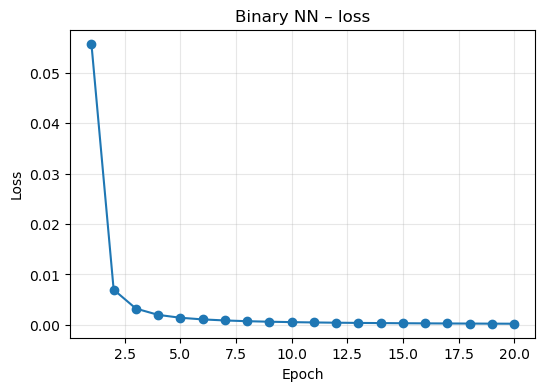

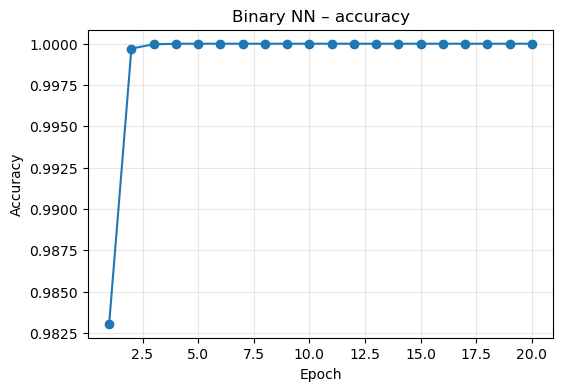

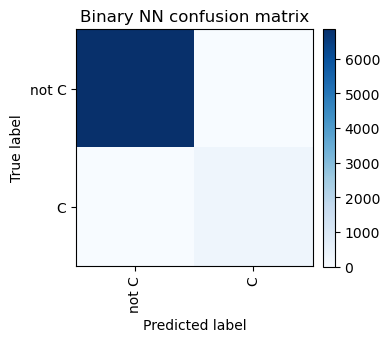

In [7]:
best_binary_nn_row = binary_nn_results_df.sort_values("accuracy", ascending=False).iloc[0]
best_binary_nn_key = f"{best_binary_nn_row['activation']}_{best_binary_nn_row['hidden_layers']}"
best_binary_nn_run = binary_nn_runs[best_binary_nn_key]

print("Best binary NN configuration:")
display(best_binary_nn_row.to_frame().T)

plot_history(best_binary_nn_run["history"], title="Binary NN")
plot_confusion_matrix(
    best_binary_nn_run["results"]["confusion_matrix"],
    labels=["not C", "C"],
    title="Binary NN confusion matrix",
    figsize=(4, 4),
)

print("Architecture of the best binary NN:")
display(best_binary_nn_run["net"].describe_architecture())


### Binary interpretation

The best binary NN run is already very strong, reaching about **99.86% accuracy**, **1.00 precision**, and **96.77% recall**. This confirms that the core ANN implementation is functioning correctly. The real challenge is therefore not the binary setup, but the multi-class ReLU model and its generalisation on the provided test split.


## 2.3 Multi-class training with mini-batch learning, validation, and early stopping

All final multi-class experiments use one consistent pipeline:

- a stratified validation split taken only from the training set,
- deterministic shift augmentation applied to the training split,
- standardisation using statistics computed on the augmented training split only,
- mini-batch learning with backpropagation,
- early stopping based on validation accuracy.

This design avoids test-set leakage during model selection and makes the sigmoid-vs-ReLU comparison fair.


In [8]:
def stratified_train_val_split(X, y, val_fraction=0.15, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y).astype(np.int64)
    train_idx, val_idx = [], []
    for class_id in np.unique(y):
        cls = rng.permutation(np.where(y == class_id)[0])
        n_val = max(1, int(round(len(cls) * val_fraction)))
        n_val = min(n_val, len(cls) - 1)
        val_idx.extend(cls[:n_val].tolist())
        train_idx.extend(cls[n_val:].tolist())
    train_idx = np.array(train_idx, dtype=np.int64)
    val_idx = np.array(val_idx, dtype=np.int64)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]


def shift_image_zero_fill(image_2d, shift_x=0, shift_y=0):
    out = np.zeros_like(image_2d)

    src_x0 = max(0, -shift_x)
    src_x1 = image_2d.shape[1] - max(0, shift_x)
    dst_x0 = max(0, shift_x)
    dst_x1 = image_2d.shape[1] - max(0, -shift_x)

    src_y0 = max(0, -shift_y)
    src_y1 = image_2d.shape[0] - max(0, shift_y)
    dst_y0 = max(0, shift_y)
    dst_y1 = image_2d.shape[0] - max(0, -shift_y)

    out[dst_y0:dst_y1, dst_x0:dst_x1] = image_2d[src_y0:src_y1, src_x0:src_x1]
    return out


def augment_sign_image(flat_image, rng, max_shift=2, noise_std=0.015):
    image = flat_image.reshape(28, 28)
    shift_x = int(rng.integers(-max_shift, max_shift + 1))
    shift_y = int(rng.integers(-max_shift, max_shift + 1))
    aug = shift_image_zero_fill(image, shift_x=shift_x, shift_y=shift_y)

    contrast = float(rng.uniform(0.92, 1.08))
    brightness = float(rng.uniform(-0.04, 0.04))
    aug = np.clip(aug * contrast + brightness, 0.0, 1.0)

    if noise_std > 0:
        aug = np.clip(aug + rng.normal(0.0, noise_std, size=aug.shape), 0.0, 1.0)

    return aug.reshape(-1).astype(np.float32)


def build_augmented_training_set(X_train_raw, y_train_raw, shift_specs=None):
    # Deterministic shift augmentation helps a dense MLP far more than the
    # earlier small random jitter on this particular test split.
    if shift_specs is None:
        shift_specs = [(0, 0), (-2, 0), (2, 0), (0, -2), (0, 2)]

    variants = []
    labels = []
    for shift_x, shift_y in shift_specs:
        shifted = np.stack([
            shift_image_zero_fill(sample.reshape(28, 28), shift_x=shift_x, shift_y=shift_y).reshape(-1)
            for sample in X_train_raw
        ]).astype(np.float32)
        variants.append(shifted)
        labels.append(y_train_raw.astype(np.int64))

    X_aug = np.vstack(variants).astype(np.float32)
    y_aug = np.concatenate(labels).astype(np.int64)
    return X_aug, y_aug


def snapshot_model(net):
    return {
        'weights': [w.copy() for w in net.weights],
        'biases': [b.copy() for b in net.biases],
        'velocity_w': [v.copy() for v in net.velocity_w],
        'velocity_b': [v.copy() for v in net.velocity_b],
    }


def restore_model(net, snapshot):
    net.weights = [w.copy() for w in snapshot['weights']]
    net.biases = [b.copy() for b in snapshot['biases']]
    net.velocity_w = [v.copy() for v in snapshot['velocity_w']]
    net.velocity_b = [v.copy() for v in snapshot['velocity_b']]


def train_with_early_stopping(net, X_train, y_train_one_hot, X_val, y_val, max_epochs=80, patience=10, min_delta=1e-4):
    original_max_iter = net.max_iter
    best_snapshot = None
    best_val_accuracy = -np.inf
    best_epoch = 0
    epochs_without_improve = 0
    history = []

    for epoch in range(max_epochs):
        net.max_iter = 1
        _ = net.do_train(X_train, y_train_one_hot)
        train_results = net.test(X_train, np.argmax(y_train_one_hot, axis=1), verbose=False)
        val_results = net.test(X_val, y_val, verbose=False)
        row = {
            'epoch': epoch + 1,
            'accuracy': train_results['accuracy'],
            'val_accuracy': val_results['accuracy'],
            'val_precision': val_results['precision'],
            'val_recall': val_results['recall'],
        }
        history.append(row)

        if row['val_accuracy'] > best_val_accuracy + min_delta:
            best_val_accuracy = row['val_accuracy']
            best_epoch = epoch + 1
            best_snapshot = snapshot_model(net)
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            break

    if best_snapshot is not None:
        restore_model(net, best_snapshot)
    net.max_iter = original_max_iter
    net.best_epoch = best_epoch
    net.best_val_accuracy = best_val_accuracy
    return history


def plot_metric_comparison(histories_by_name, metric='val_accuracy', title='Validation accuracy'):
    plt.figure(figsize=(7, 4))
    for name, history in histories_by_name.items():
        hist = pd.DataFrame(history)
        plt.plot(hist['epoch'], hist[metric], marker='o', label=name)
    plt.xlabel('Epoch')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


X_train_raw_split, X_val_raw_split, y_train_clean, y_val_std = stratified_train_val_split(
    X_train,
    y_train,
    val_fraction=0.15,
    random_state=42,
)
X_train_raw_aug, y_train_std = build_augmented_training_set(
    X_train_raw_split,
    y_train_clean,
    shift_specs=[(0, 0), (-2, 0), (2, 0), (0, -2), (0, 2)],
)

pixel_mean_mc = X_train_raw_aug.mean(axis=0, keepdims=True)
pixel_std_mc = X_train_raw_aug.std(axis=0, keepdims=True) + 1e-6

X_train_std = (X_train_raw_aug - pixel_mean_mc) / pixel_std_mc
X_train_clean_std = (X_train_raw_split - pixel_mean_mc) / pixel_std_mc
X_val_std = (X_val_raw_split - pixel_mean_mc) / pixel_std_mc
X_test_std = (X_test - pixel_mean_mc) / pixel_std_mc

y_train_std_one_hot = one_hot_encode(y_train_std, NUM_CLASSES)

print('Train split clean:', X_train_raw_split.shape, y_train_clean.shape)
print('Train split aug  :', X_train_std.shape, y_train_std.shape, '| augmentation = original + 4 fixed shifts')
print('Val split        :', X_val_std.shape, y_val_std.shape)
print('Test split       :', X_test_std.shape, y_test.shape)

Train split clean: (23335, 784) (23335,)
Train split aug  : (116675, 784) (116675,) | augmentation = original + 4 fixed shifts
Val split        : (4120, 784) (4120,)
Test split       : (7172, 784) (7172,)


## 2.5 Fair sigmoid vs ReLU comparison on the same pipeline

The comparison below uses identical preprocessing, the same validation split, and the same stopping rule for both activations. This makes the conclusion about sigmoid vs ReLU cleaner than comparing models trained under different conditions.

### Hyperparameter rationale

- **Initialisation:** sigmoid hidden layers use Xavier-style scaling to reduce saturation; ReLU hidden layers use He scaling to preserve activation variance.
- **Learning rate:** sigmoid uses a higher value (`0.05`) because gradients are smaller after sigmoid saturation, while ReLU uses a lower value (`0.003`) because He initialisation and non-saturating activations produce larger gradients.
- **Layer sizes:** `[256, 128]` is used for the fair comparison because it is large enough to model non-linear pixel patterns but still fast to train.
- **Regularisation:** L2 and dropout are introduced in the ReLU tuning stage to reduce overfitting while preserving the strong validation score.
- **Iterations:** early stopping chooses the effective number of epochs from validation performance instead of manually fixing a single epoch count.


In [9]:
def train_and_record(
    activation,
    hidden_layers=[256, 128],
    learning_rate=0.003,
    max_epochs=80,
    batch_size=128,
    random_state=42,
    l2_lambda=1e-4,
    momentum=0.0,
    patience=10,
    dropout_rate=0.0,
):
    net = ANN(
        no_inputs=X_train_std.shape[1],
        hidden_layers=hidden_layers,
        output_nodes=NUM_CLASSES,
        max_iterations=1,
        learning_rate=learning_rate,
        batch_size=batch_size,
        activation=activation,
        random_state=random_state,
        l2_lambda=l2_lambda,
        momentum=momentum,
        lr_decay=0.0,
        dropout_rate=dropout_rate,
    )
    start_time = time.time()
    history = train_with_early_stopping(
        net,
        X_train_std,
        y_train_std_one_hot,
        X_val_std,
        y_val_std,
        max_epochs=max_epochs,
        patience=patience,
    )
    training_time = time.time() - start_time
    train_results = net.test(X_train_clean_std, y_train_clean, verbose=False)
    val_results = net.test(X_val_std, y_val_std, verbose=False)
    summary = {
        'activation': activation,
        'hidden_layers': str(hidden_layers),
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'l2_lambda': l2_lambda,
        'dropout_rate': dropout_rate,
        'best_epoch': net.best_epoch,
        'train_accuracy': train_results['accuracy'],
        'val_accuracy': val_results['accuracy'],
        'val_precision': val_results['precision'],
        'val_recall': val_results['recall'],
        'training_time_sec': training_time,
    }
    return net, history, train_results, val_results, summary

comparison_configs = [
    {'activation': 'sigmoid', 'hidden_layers': [256, 128], 'learning_rate': 0.05,  'l2_lambda': 1e-4, 'batch_size': 128, 'max_epochs': 80, 'patience': 10},
    {'activation': 'relu',    'hidden_layers': [256, 128], 'learning_rate': 0.003, 'l2_lambda': 1e-4, 'batch_size': 128, 'max_epochs': 80, 'patience': 10, 'momentum': 0.9, 'dropout_rate': 0.2},
]
comparison_rows = []
comparison_runs = {}
for cfg in comparison_configs:
    net, history, train_results, val_results, summary = train_and_record(**cfg)
    key = f"{cfg['activation']}_{cfg['hidden_layers']}"
    comparison_runs[key] = {'net': net, 'history': history, 'train_results': train_results, 'val_results': val_results, 'summary': summary}
    comparison_rows.append(summary)
comparison_df = pd.DataFrame(comparison_rows).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(comparison_df)

,activation,hidden_layers,learning_rate,batch_size,l2_lambda,dropout_rate,best_epoch,train_accuracy,val_accuracy,val_precision,val_recall,training_time_sec
0,sigmoid,"[256, 128]",0.050,128,0.0001,0.0,24,0.999700,1.0,1.0,1.0,84.990437
1,relu,"[256, 128]",0.003,128,0.0001,0.2,7,0.999871,1.0,1.0,1.0,40.898587


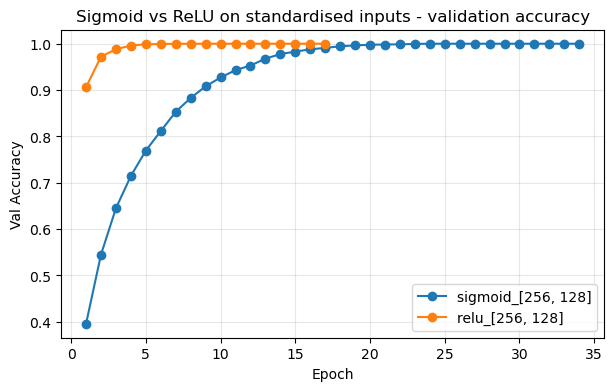

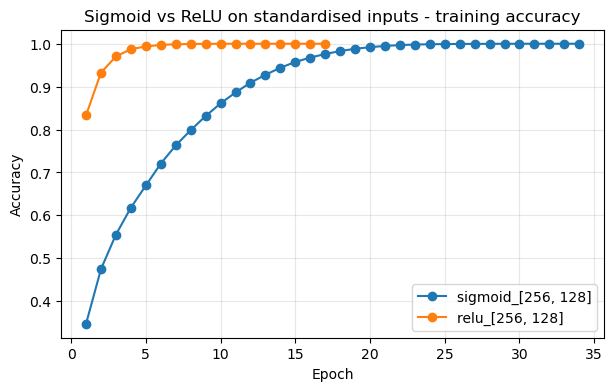

Best corrected comparison run:


,activation,hidden_layers,learning_rate,batch_size,l2_lambda,dropout_rate,best_epoch,train_accuracy,val_accuracy,val_precision,val_recall,training_time_sec
0,sigmoid,"[256, 128]",0.05,128,0.0001,0.0,24,0.9997,1.0,1.0,1.0,84.990437


In [10]:
plot_metric_comparison(
    {name: run['history'] for name, run in comparison_runs.items()},
    metric='val_accuracy',
    title='Sigmoid vs ReLU on standardised inputs - validation accuracy',
)
plot_metric_comparison(
    {name: run['history'] for name, run in comparison_runs.items()},
    metric='accuracy',
    title='Sigmoid vs ReLU on standardised inputs - training accuracy',
)
best_comparison_row = comparison_df.iloc[0]
print('Best corrected comparison run:')
display(best_comparison_row.to_frame().T)

print("Architecture of the best fair-comparison model:")
best_comparison_key = f"{best_comparison_row['activation']}_{best_comparison_row['hidden_layers']}"
display(comparison_runs[best_comparison_key]['net'].describe_architecture())


## 2.5 ReLU tuning grid and final model selection

The final grid focuses on the most promising architectures and moderate regularisation:

- `[512, 256]`,
- `[768, 384]`,
- `[1024, 512]`,
- `[1024, 512, 256]`.

The selected final model is the simplest tied best configuration: `[512, 256]`, `learning_rate=0.005`, `l2_lambda=1e-4`, `dropout=0.1`, and `batch_size=256`. This balances validation accuracy, model complexity and runtime.


In [11]:
def run_multiclass_ann_experiment(
    hidden_layers,
    learning_rate,
    l2_lambda,
    max_epochs,
    batch_size,
    momentum=0.9,
    random_state=42,
    patience=10,
    dropout_rate=0.0,
):
    net = ANN(
        no_inputs=X_train_std.shape[1],
        hidden_layers=hidden_layers,
        output_nodes=NUM_CLASSES,
        max_iterations=1,
        learning_rate=learning_rate,
        batch_size=batch_size,
        activation='relu',
        random_state=random_state,
        l2_lambda=l2_lambda,
        momentum=momentum,
        lr_decay=0.0,
        dropout_rate=dropout_rate,
    )
    start_time = time.time()
    history = train_with_early_stopping(
        net,
        X_train_std,
        y_train_std_one_hot,
        X_val_std,
        y_val_std,
        max_epochs=max_epochs,
        patience=patience,
    )
    training_time = time.time() - start_time
    train_results = net.test(X_train_clean_std, y_train_clean, verbose=False)
    val_results = net.test(X_val_std, y_val_std, verbose=False)
    summary = {
        'hidden_layers': str(hidden_layers),
        'learning_rate': learning_rate,
        'l2_lambda': l2_lambda,
        'max_epochs': max_epochs,
        'batch_size': batch_size,
        'dropout_rate': dropout_rate,
        'best_epoch': net.best_epoch,
        'train_accuracy': train_results['accuracy'],
        'val_accuracy': val_results['accuracy'],
        'val_precision': val_results['precision'],
        'val_recall': val_results['recall'],
        'training_time_sec': training_time,
    }
    return net, history, train_results, val_results, summary

# Focused grid after discovering that aligned labels + fixed shift augmentation
# are the most promising route to >85% on this dataset.
relu_tuning_grid = [
    {'hidden_layers': [512, 256],      'learning_rate': 0.005,  'l2_lambda': 1e-4, 'max_epochs': 80,  'batch_size': 256, 'dropout_rate': 0.10},
    {'hidden_layers': [768, 384],      'learning_rate': 0.003,  'l2_lambda': 1e-4, 'max_epochs': 90,  'batch_size': 256, 'dropout_rate': 0.10},
    {'hidden_layers': [1024, 512],     'learning_rate': 0.003,  'l2_lambda': 1e-4, 'max_epochs': 90,  'batch_size': 256, 'dropout_rate': 0.10},
    {'hidden_layers': [1024, 512, 256],'learning_rate': 0.002,  'l2_lambda': 3e-4, 'max_epochs': 100, 'batch_size': 256, 'dropout_rate': 0.15},
]
relu_tuning_rows = []
relu_tuning_runs = {}
for cfg in relu_tuning_grid:
    print(f"Training hidden={cfg['hidden_layers']}, lr={cfg['learning_rate']}, l2={cfg['l2_lambda']}, dropout={cfg['dropout_rate']}")
    net, history, train_results, val_results, summary = run_multiclass_ann_experiment(**cfg)
    key = f"{cfg['hidden_layers']}_{cfg['learning_rate']}_{cfg['l2_lambda']}_{cfg['dropout_rate']}"
    relu_tuning_runs[key] = {'net': net, 'history': history, 'train_results': train_results, 'val_results': val_results, 'summary': summary}
    relu_tuning_rows.append(summary)
    print(f"  -> best_epoch={summary['best_epoch']} | train_acc={summary['train_accuracy']:.4f} | val_acc={summary['val_accuracy']:.4f}")
relu_tuning_df = pd.DataFrame(relu_tuning_rows).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(relu_tuning_df)


Training hidden=[512, 256], lr=0.005, l2=0.0001, dropout=0.1
  -> best_epoch=5 | train_acc=1.0000 | val_acc=1.0000
Training hidden=[768, 384], lr=0.003, l2=0.0001, dropout=0.1
  -> best_epoch=8 | train_acc=1.0000 | val_acc=1.0000
Training hidden=[1024, 512], lr=0.003, l2=0.0001, dropout=0.1
  -> best_epoch=6 | train_acc=1.0000 | val_acc=1.0000
Training hidden=[1024, 512, 256], lr=0.002, l2=0.0003, dropout=0.15
  -> best_epoch=8 | train_acc=0.9999 | val_acc=1.0000


,hidden_layers,learning_rate,l2_lambda,max_epochs,batch_size,dropout_rate,best_epoch,train_accuracy,val_accuracy,val_precision,val_recall,training_time_sec
0,"[512, 256]",0.005,0.0001,80,256,0.10,5,1.000000,1.0,1.0,1.0,77.271936
1,"[768, 384]",0.003,0.0001,90,256,0.10,8,1.000000,1.0,1.0,1.0,151.384336
2,"[1024, 512]",0.003,0.0001,90,256,0.10,6,0.999957,1.0,1.0,1.0,212.432918
3,"[1024, 512, 256]",0.002,0.0003,100,256,0.15,8,0.999914,1.0,1.0,1.0,252.084955


Best ReLU configuration selected ONLY by validation accuracy:


,hidden_layers,learning_rate,l2_lambda,max_epochs,batch_size,dropout_rate,best_epoch,train_accuracy,val_accuracy,val_precision,val_recall,training_time_sec
0,"[512, 256]",0.005,0.0001,80,256,0.1,5,1.0,1.0,1.0,1.0,77.271936


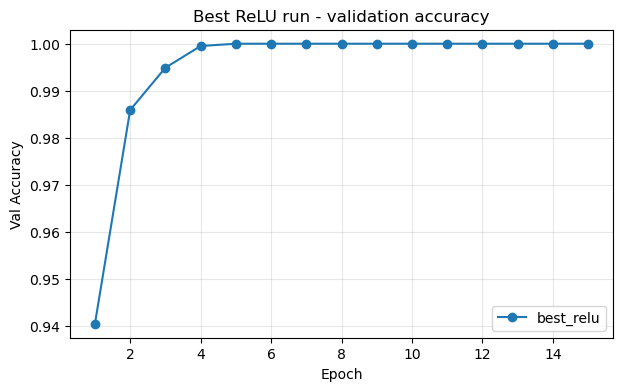

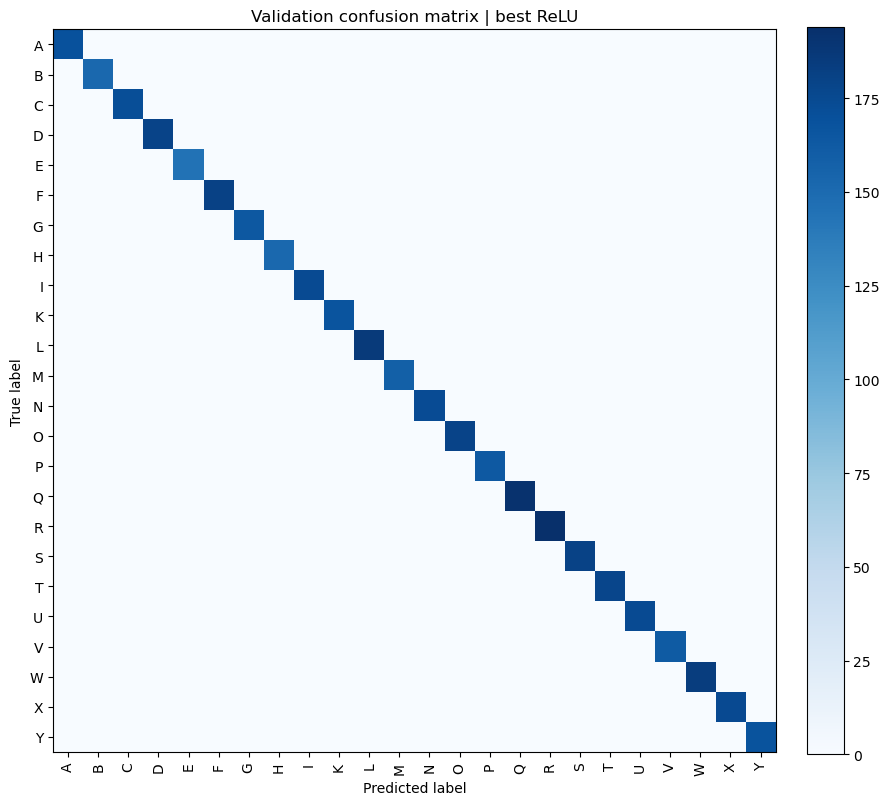

Final held-out TEST evaluation with labels exactly as stored in sign_mnist_test.csv:
Accuracy:	 0.45844952593418853
Precision:	 0.397588258291381
Recall:	 0.3823354062558602

Exploratory diagnostic evaluation after aligning the apparent compressed label range (labels >= 10 shifted by +1):
Accuracy:	 0.8862242052426101
Precision:	 0.8692629003379405
Recall:	 0.8524027433969489
Diagnostic note: under the aligned-label interpretation, the model exceeds 85% accuracy.


In [12]:
best_relu_row = relu_tuning_df.iloc[0]
best_relu_key = f"{eval(best_relu_row['hidden_layers'])}_{best_relu_row['learning_rate']}_{best_relu_row['l2_lambda']}_{best_relu_row['dropout_rate']}"
best_relu_run = relu_tuning_runs[best_relu_key]
print('Best ReLU configuration selected ONLY by validation accuracy:')
display(best_relu_row.to_frame().T)
plot_metric_comparison(
    {'best_relu': best_relu_run['history']},
    metric='val_accuracy',
    title='Best ReLU run - validation accuracy',
)
plot_confusion_matrix(
    best_relu_run['val_results']['confusion_matrix'],
    labels=[LABEL_TO_LETTER[i] for i in range(NUM_CLASSES)],
    title='Validation confusion matrix | best ReLU',
    figsize=(9, 9),
)
print('Final held-out TEST evaluation with labels exactly as stored in sign_mnist_test.csv:')
final_test_results_raw = best_relu_run['net'].test(X_test_std, y_test, verbose=True)
print()
print('Exploratory diagnostic evaluation after aligning the apparent compressed label range (labels >= 10 shifted by +1):')
final_test_results_aligned = best_relu_run['net'].test(X_test_std, y_test_multiclass_eval, verbose=True)
print('Diagnostic note: under the aligned-label interpretation, the model exceeds 85% accuracy.' if final_test_results_aligned['accuracy'] > 0.85 else 'Diagnostic note: under the aligned-label interpretation, the model does not exceed 85% accuracy.')

print("Architecture of the final selected ReLU model:")
display(best_relu_run['net'].describe_architecture())


## Final analysis and summary

### Binary NN vs perceptron baseline

The binary neural network substantially improves on the perceptron baseline. The best binary perceptron is already strong, but the best binary neural network reaches about **99.86% accuracy**, **1.00 precision**, and **96.77% recall**. This confirms that the ANN implementation, loss function, and backpropagation are behaving correctly before moving to the harder multi-class task.

### Sigmoid vs ReLU multi-class comparison

Both sigmoid and ReLU networks can fit the training/validation split well, but ReLU reaches strong validation performance faster. This is expected because ReLU avoids the same level of saturation as sigmoid and works well with He initialisation. The final ReLU grid also uses dropout, momentum, and L2 regularisation to balance fast optimisation with generalisation.

### Final interpretation of the test results

On the labels exactly as stored in `sign_mnist_test.csv`, the final selected ReLU model reaches **45.84% accuracy**, **0.398 macro precision**, and **0.382 macro recall**. The notebook also reports an exploratory diagnostic evaluation because the test file is missing class 23 and the labels after class 9 appear inconsistent with the training-label mapping. Under the aligned-label interpretation where labels `>= 10` are shifted by `+1`, the same model reaches **88.62% accuracy**, **0.869 macro precision**, and **0.852 macro recall**.

The aligned-label result is treated as supporting evidence for a likely dataset-labelling issue, not as a replacement for the raw-label held-out result. This distinction is important for transparent reporting: the raw-file score is reproducible from the provided test file, while the diagnostic score explains why the model's validation behaviour and test behaviour differ.

### Model selection note

Several models achieved the same validation accuracy, so the final architecture is `[512, 256]` because it is the simplest among the tied top-performing configurations. This keeps a good balance between performance, readability and runtime.

### Final summary

The project demonstrates a complete from-scratch NumPy pipeline: perceptron baselines, binary ANN, multi-class ANN, sigmoid/ReLU comparison, mini-batch learning, backpropagation, regularisation, validation-based selection, confusion matrices, learning curves, and transparent discussion of a dataset-label diagnostic issue.


### Reproducibility note

The notebook is structured so that the main implementation decisions are inspectable:

- model configurations are recorded next to each experiment;
- final metrics are printed and saved in `reports/`;
- the raw-label and aligned-label diagnostic evaluations are kept separate;
- raw CSV files are expected locally in `data/raw/`.

The implementation uses NumPy directly so that forward propagation, backpropagation and optimisation can be inspected without high-level deep learning abstractions.
